# Обучение и сравнение моделей расходов СберИндекса
Данные: Россия, 5 расходных категорий, 93 месяца. Горизонты 1/3/6/12 месяцев. Метрики MAE в млрд руб., R² и coverage. Муниципальные расходы пока отсутствуют. Используется одна текущая версия истории; задержки публикации неизвестны. Параметры выбраны на dev и заморожены до holdout.
Обучение воспроизводится скриптом `scripts/train_forecasts.py`; notebook читает сохранённый run и создаёт таблицы/графики/PDF. Если run отсутствует, обучение запускается автоматически. Для нового независимого эксперимента явно измените конфигурацию, не подбирая её по опубликованному holdout.

In [1]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 't_dict_municipal').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
latest = ROOT / 'artifacts/forecast_runs/latest.json'
if not latest.exists():
    subprocess.run([sys.executable, str(ROOT / 'scripts/train_forecasts.py')], cwd=ROOT, check=True)
pointer = json.loads(latest.read_text())
RUN = ROOT / pointer['directory']
manifest = json.loads((RUN / 'manifest.json').read_text())
selection = json.loads((RUN / 'frozen_selection.json').read_text())
metrics = pd.read_csv(RUN / 'metrics.csv')
per_series = pd.read_csv(RUN / 'per_series_metrics.csv')
predictions = pd.read_csv(RUN / 'predictions.csv')
display(pd.Series(manifest, name='value').to_frame())
display(pd.read_csv(RUN / 'model_status.csv'))

,value
run_id,national_20261003T112832_522037Z
input,consumer-spending_ru_1788769445732.csv.zip
data_sha256,cbf4bb5d464a083b95500f4a3d65ce081a8695b7b2966a...
config_sha256,18fe4d0e1e004608bd2f95f7a645a709885dfe93c7db84...
code_sha256,8d7df26828f6d7597f9081aed5a931523efc6aec7689bc...
split_sha256,ea42e4ca9c1f856ed043173cae6932ab451f151cc4d2d5...
python,"3.14.4 | packaged by Anaconda, Inc. | (main, A..."
packages,"{'numpy': '2.4.5', 'pandas': '3.0.3', 'scipy':..."
statsmodels_python,/home/bugor/miniconda3/envs/trend/bin/python
statsmodels_version,0.15.0


,model,status,reason
0,CatBoostDirect,available,NaN
1,FourierRidge,available,NaN
2,HoltWinters,available,NaN
3,LastValue,available,NaN
4,RandomForestDirect,available,NaN
5,RidgeDirect,available,NaN
6,SeasonalGrowth,available,NaN
7,SeasonalNaive,available,NaN
8,Prophet,not_run,Пакет/checkpoint недоступен в текущем окружени...
9,Chronos,not_run,Пакет/checkpoint недоступен в текущем окружени...


In [2]:
split = pd.read_csv(RUN / 'split_manifest.csv', parse_dates=['origin','target_date'])
display(split.groupby(['stage','horizon_months']).agg(origins=('origin','nunique'),first_origin=('origin','min'),last_origin=('origin','max'),first_target=('target_date','min'),last_target=('target_date','max')))
assert (split[split.stage == 'development'].target_date < pd.Timestamp(manifest['holdout_start'])).all()
assert selection['holdout_hyperparameters_changed'] is False
display(Markdown('Origin — последний доступный контекстный месяц по допущению эксперимента. Фактическую задержку публикации этот набор не кодирует. Последние 12 целевых месяцев теста не использованы для выбора параметров; на тесте переобучение идёт по фиксированному правилу.'))
display(pd.DataFrame(selection['best_variant_per_family']))
print('Выбор до открытия holdout:', selection['selected_model_on_development'])

Выбор до открытия holdout: DevWeightedEnsemble


origins first_origin  ... first_target last_target
stage       horizon_months                        ...                         
development 1                    34   2021-11-01  ...   2021-12-01  2024-09-01
            3                    34   2021-11-01  ...   2022-02-01  2024-11-01
            6                    34   2021-11-01  ...   2022-05-01  2025-02-01
            12                   34   2021-11-01  ...   2022-11-01  2025-08-01
holdout     1                    12   2025-08-01  ...   2025-09-01  2026-08-01
            3                    12   2025-06-01  ...   2025-09-01  2026-08-01
            6                    12   2025-03-01  ...   2025-09-01  2026-08-01
            12                   12   2024-09-01  ...   2025-09-01  2026-08-01

[8 rows x 5 columns]

Origin — последний доступный контекстный месяц по допущению эксперимента. Фактическую задержку публикации этот набор не кодирует. Последние 12 целевых месяцев теста не использованы для выбора параметров; на тесте переобучение идёт по фиксированному правилу.

,model,variant,macro_mae
0,CatBoostDirect,catboost_d3,90.716364
1,RandomForestDirect,forest,95.058636
2,HoltWinters,hw_add,97.229649
3,FourierRidge,fourier_36,125.083491
4,SeasonalGrowth,seasonal_growth,135.657516
5,RidgeDirect,ridge_10,137.248840
6,LastValue,last_value,187.390412
7,SeasonalNaive,seasonal_naive,280.535338


In [3]:
for stage in ['development','holdout']:
    display(Markdown('### ' + stage + ': MAE по категориям, млрд руб.'))
    table = metrics[metrics.stage == stage].pivot(index='model', columns='horizon_months', values='macro_mae')
    table['mean_MAE'] = table.mean(axis=1)
    display(table.sort_values('mean_MAE').round(3))
display(Markdown('### R² для временной динамики внутри каждой категории'))
display(per_series[per_series.stage == 'holdout'].groupby(['model','series_id']).r2.mean().unstack().round(3))
display(Markdown('Pooled R² сохраняется в metrics.csv, но может скрывать ошибки динамики из-за разного масштаба категорий. Отрицательные значения не обрезаются. Категория Всего не является шестой независимой суммой и не складывается с детализацией.'))
display(metrics.groupby('stage').coverage.agg(['min','max']))
display(pd.read_csv(RUN / 'paired_bootstrap.csv').round(3))

### development: MAE по категориям, млрд руб.

horizon_months,1,3,6,12,mean_MAE
model,,,,,
DevWeightedEnsemble,43.886,69.130,96.787,128.122,84.481
CatBoostDirect,59.116,81.728,104.246,117.775,90.716
RandomForestDirect,59.002,88.145,110.259,122.828,95.059
HoltWinters,38.828,71.885,107.721,170.485,97.230
FourierRidge,125.028,131.771,121.395,122.139,125.083
SeasonalGrowth,105.964,133.697,155.964,147.006,135.658
RidgeDirect,82.865,119.309,141.381,205.440,137.249
LastValue,113.070,124.872,196.609,315.012,187.390
SeasonalNaive,265.046,267.494,274.590,315.012,280.535


### holdout: MAE по категориям, млрд руб.

horizon_months,1,3,6,12,mean_MAE
model,,,,,
DevWeightedEnsemble,70.053,82.867,81.978,63.760,74.664
CatBoostDirect,62.717,78.531,86.730,87.659,78.909
SeasonalGrowth,66.025,77.811,91.354,112.759,86.987
RandomForestDirect,67.685,91.709,96.876,101.446,89.429
HoltWinters,90.692,112.394,137.701,138.288,119.769
FourierRidge,118.437,111.722,122.724,149.476,125.590
RidgeDirect,116.103,154.301,155.511,169.145,148.765
LastValue,177.165,223.211,290.505,346.620,259.375
SeasonalNaive,346.620,346.620,346.620,346.620,346.620


### R² для временной динамики внутри каждой категории

series_id,Всего,Непродовольственные товары,Общественное питание,Продовольственные товары,Услуги
model,,,,,
CatBoostDirect,0.827,0.762,-0.823,0.801,0.766
DevWeightedEnsemble,0.858,0.737,-1.860,0.821,0.881
FourierRidge,0.501,0.421,-1.579,0.465,0.533
HoltWinters,0.571,0.489,-1.953,0.725,0.152
LastValue,-1.131,-1.010,-3.817,-0.722,-2.866
RandomForestDirect,0.860,0.719,-8.699,0.739,0.772
RidgeDirect,0.396,0.341,0.056,0.282,-1.055
SeasonalGrowth,0.880,0.805,-9.443,0.750,0.750
SeasonalNaive,-1.957,-0.991,-13.427,-0.191,-9.789


Pooled R² сохраняется в metrics.csv, но может скрывать ошибки динамики из-за разного масштаба категорий. Отрицательные значения не обрезаются. Категория Всего не является шестой независимой суммой и не складывается с детализацией.

,min,max
stage,,
development,1.0,1.0
holdout,1.0,1.0


,candidate,baseline,difference_mae,ci_low,ci_high,n_target_months,block_months,replicates
0,DevWeightedEnsemble,SeasonalNaive,-271.955,-312.154,-219.100,12,3,1000
1,DevWeightedEnsemble,SeasonalGrowth,-12.323,-18.201,-5.984,12,3,1000


,value
selected_model,DevWeightedEnsemble
mean_test_mae,74.664447
improvement_vs_seasonal_naive_pct,78.459269
figures,"[validation_timeline, mae_heatmap, model_ranki..."
pdf,artifacts/forecast_runs/national_20261003T1128...
report,docs/NATIONAL_FORECAST_RESULTS_RU.md


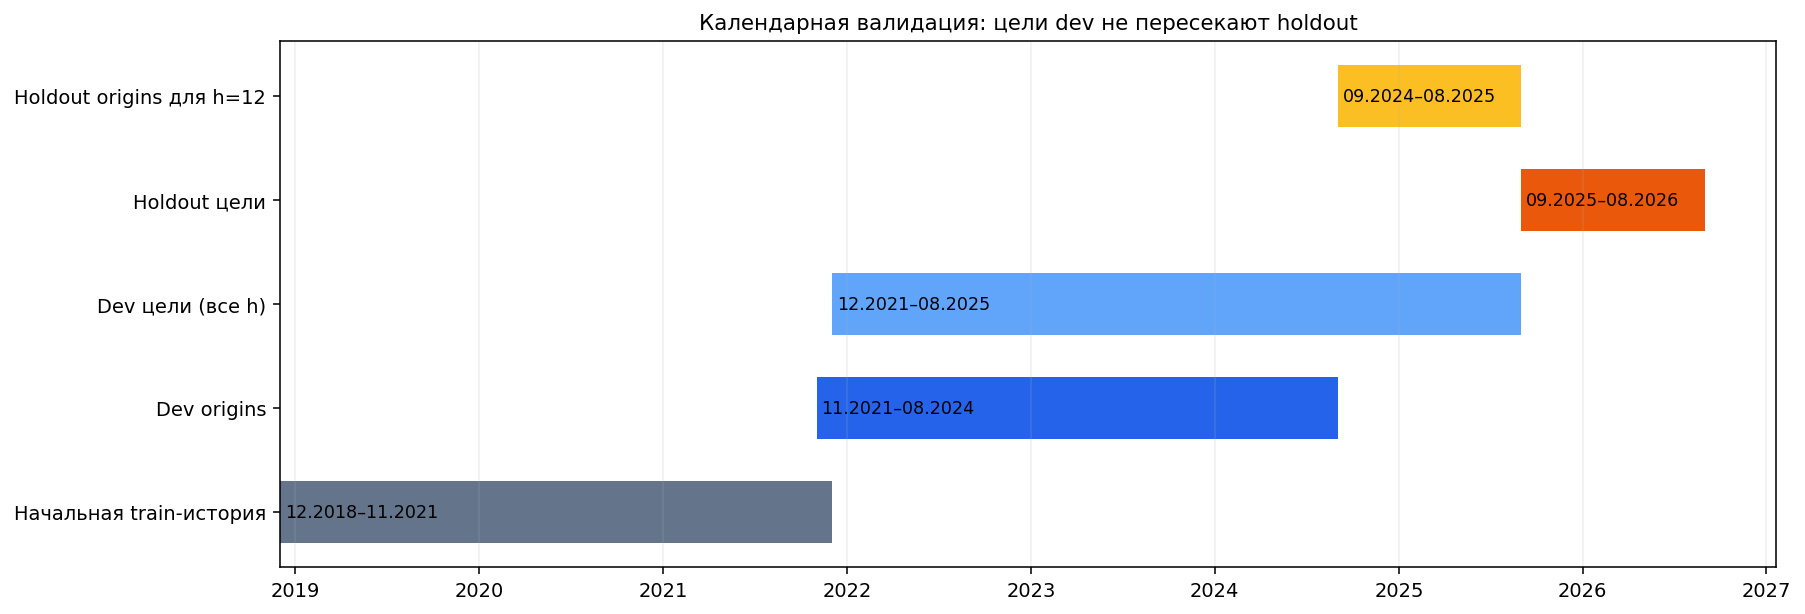

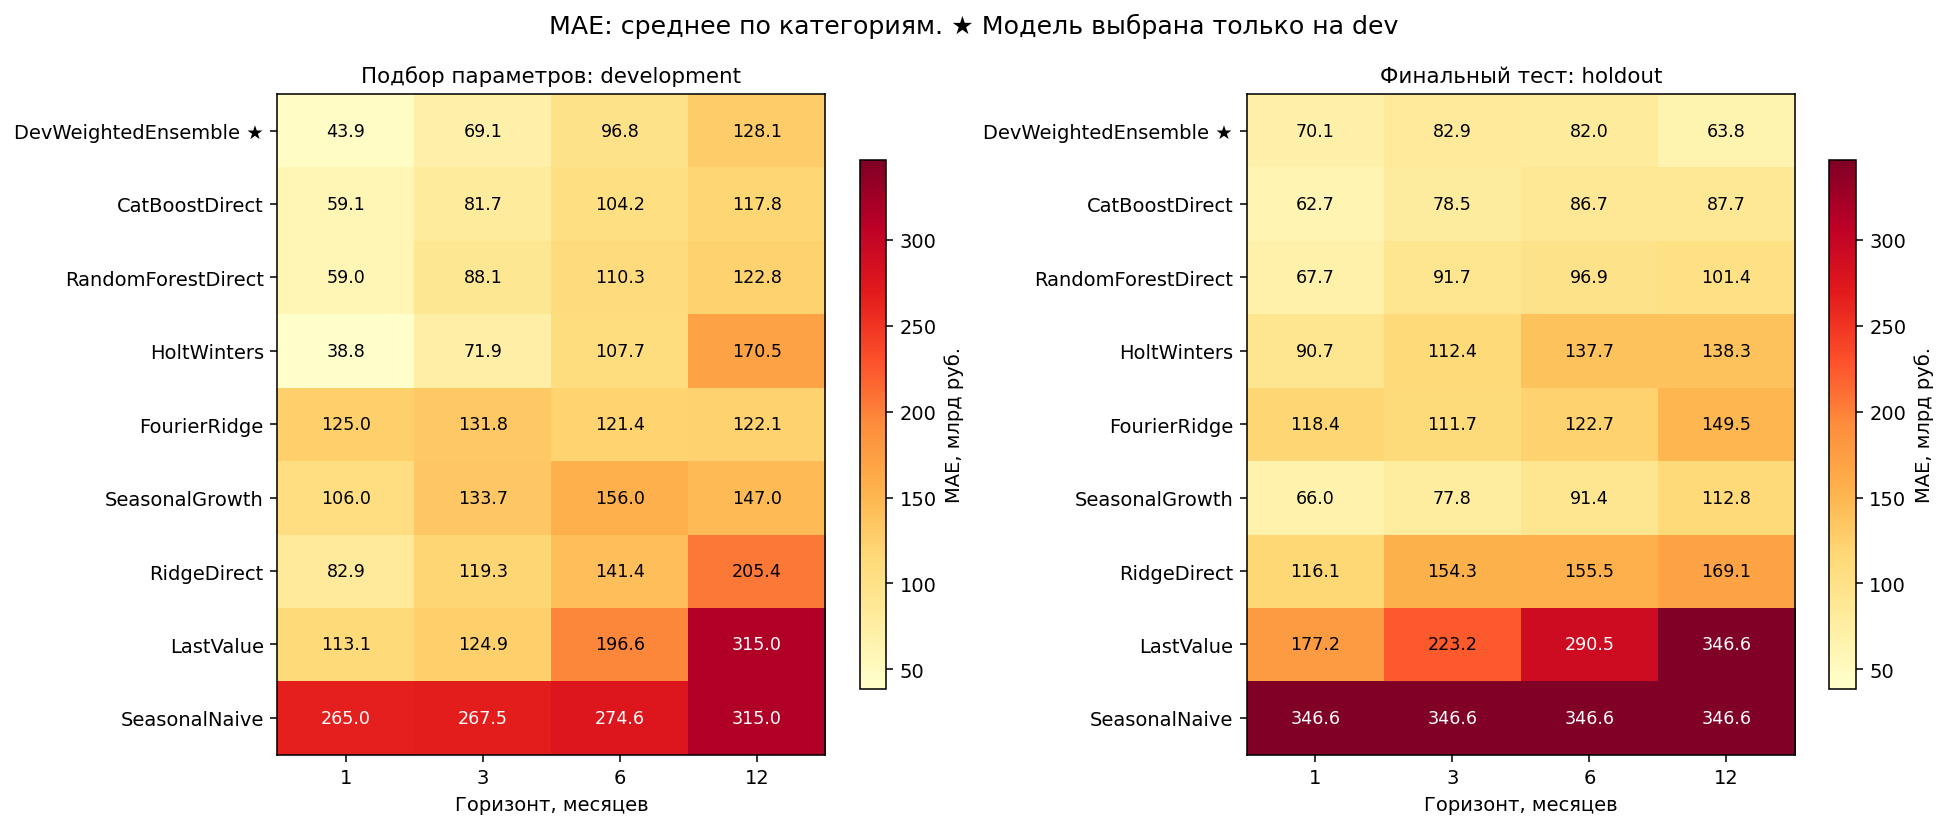

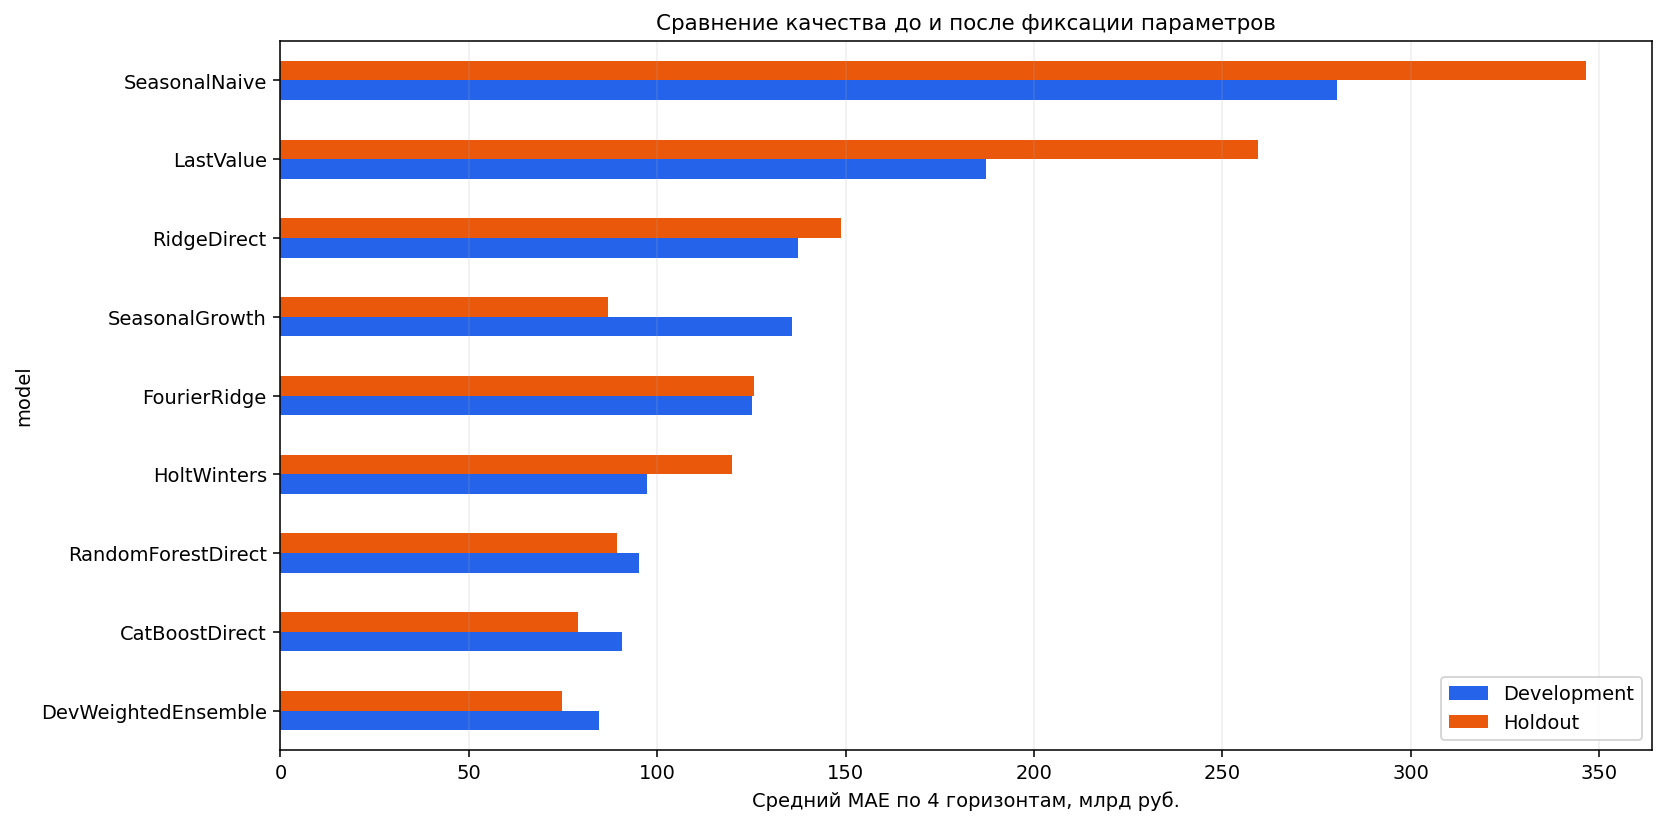

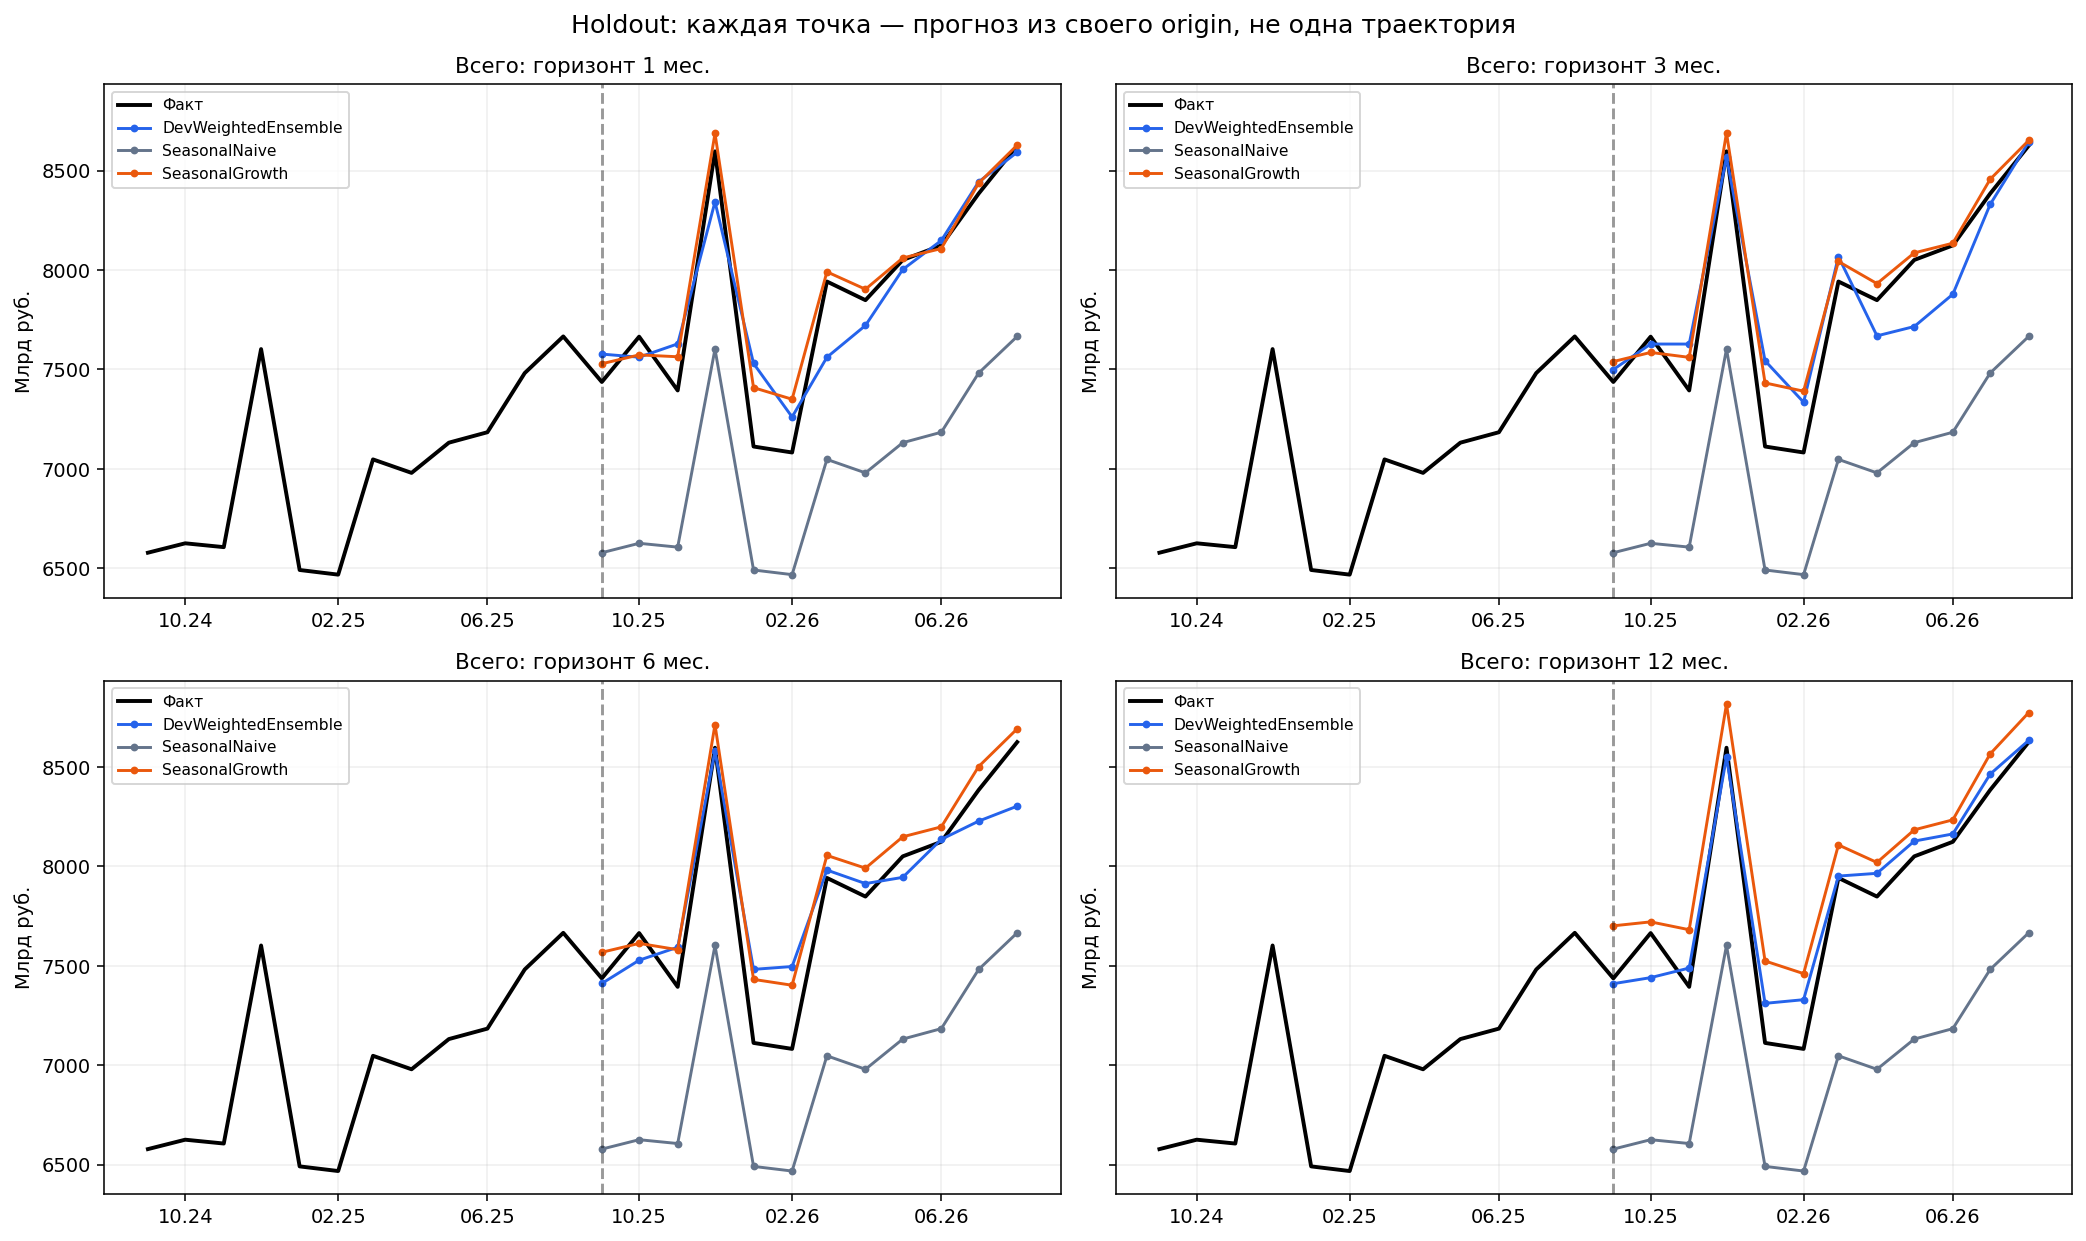

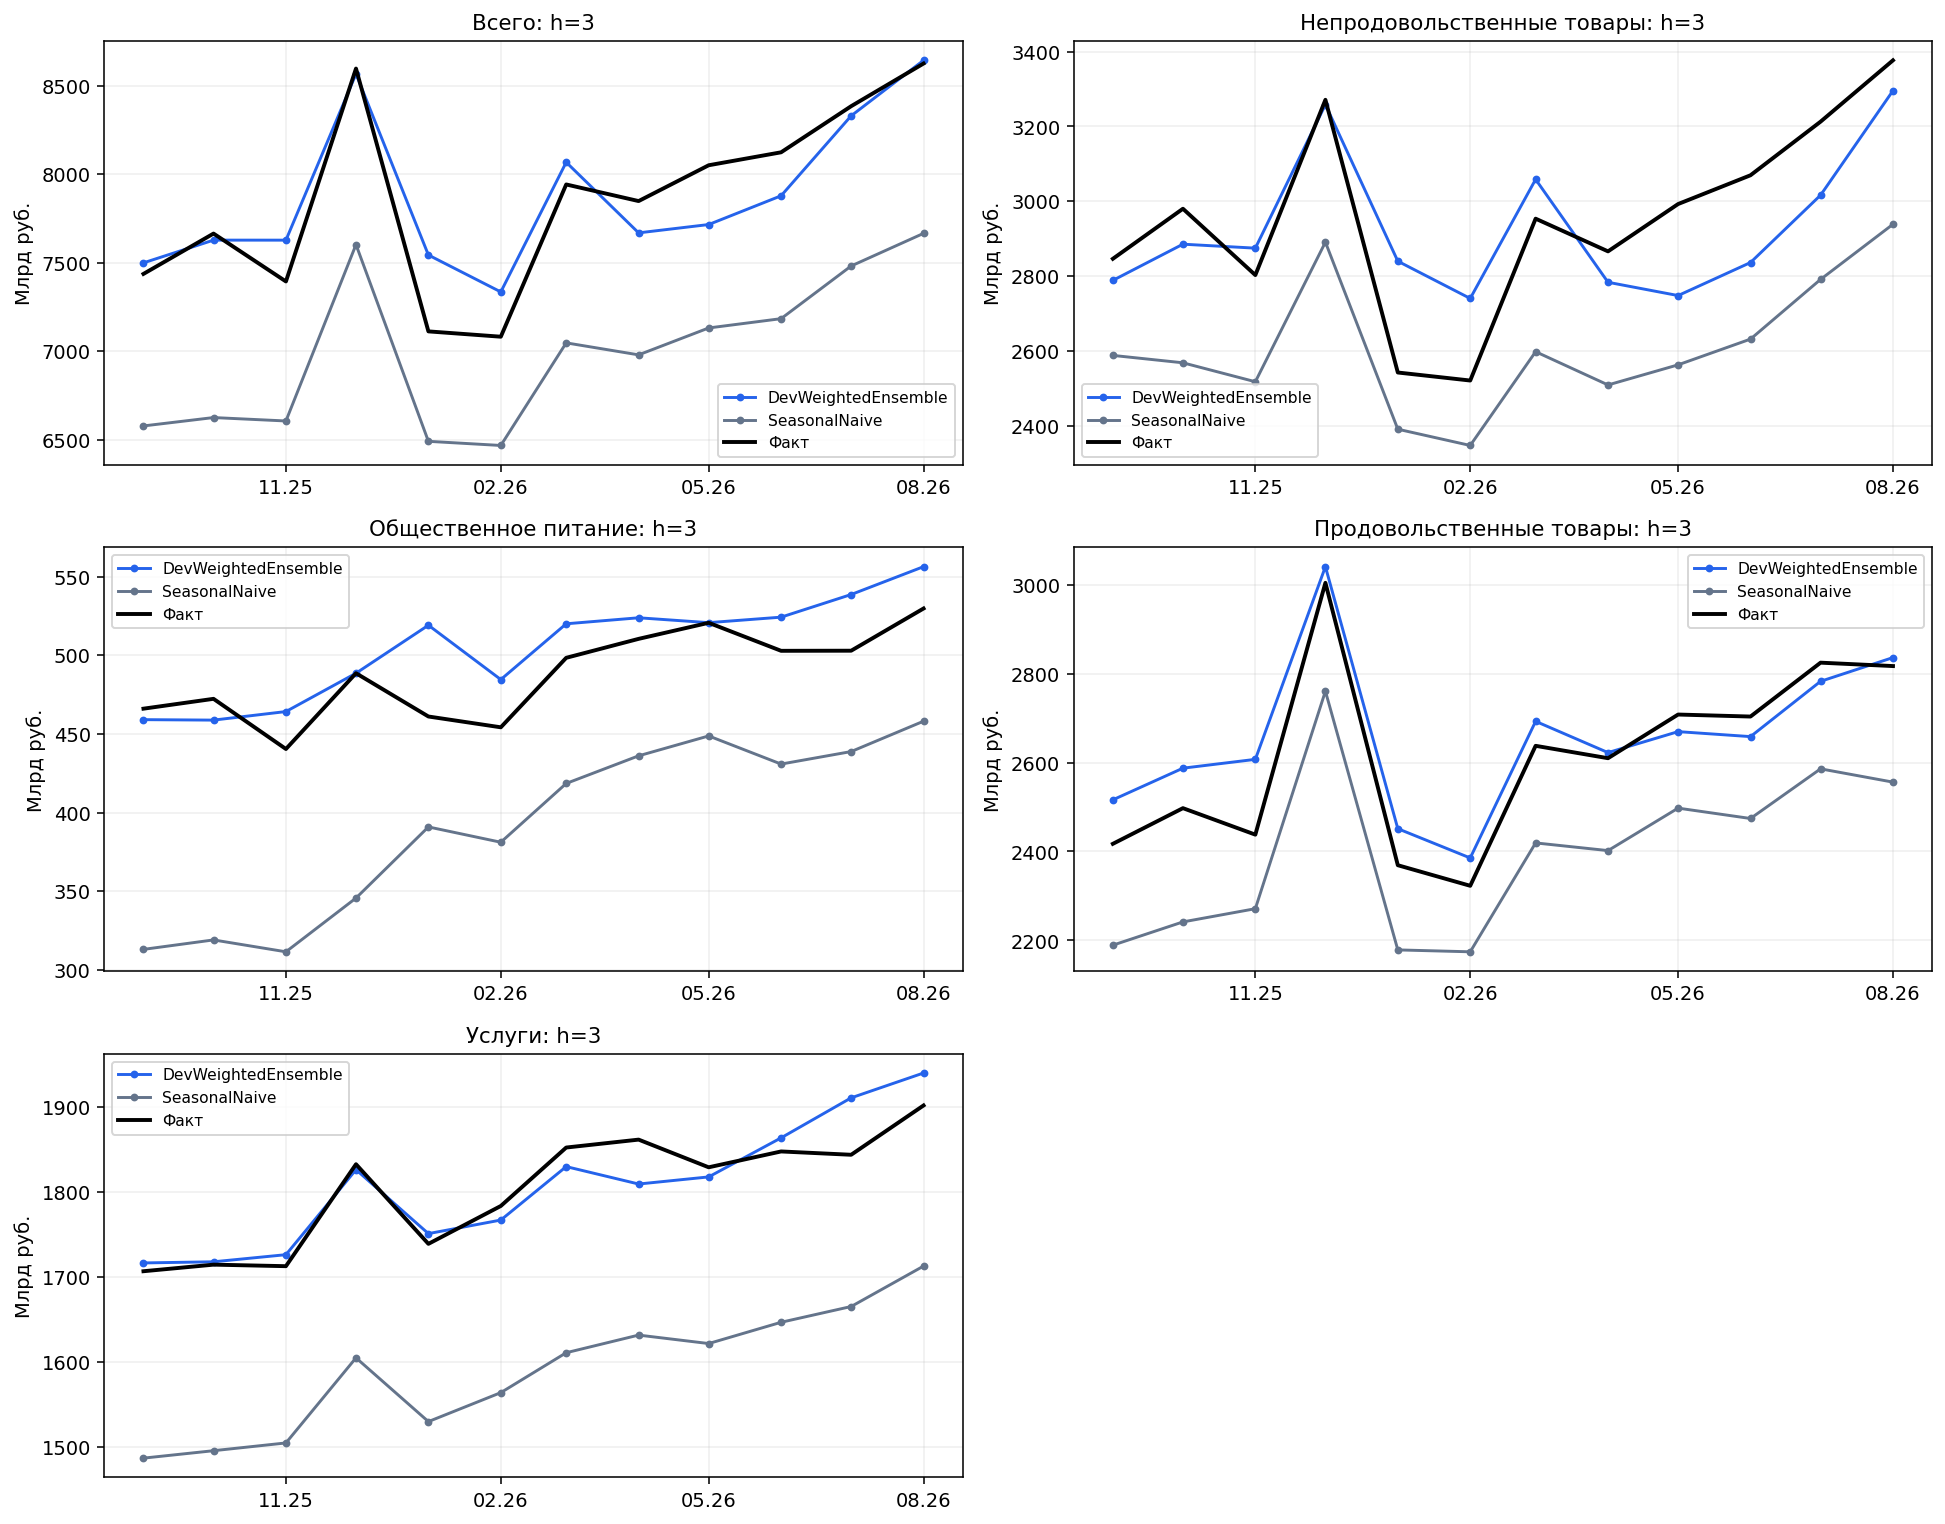

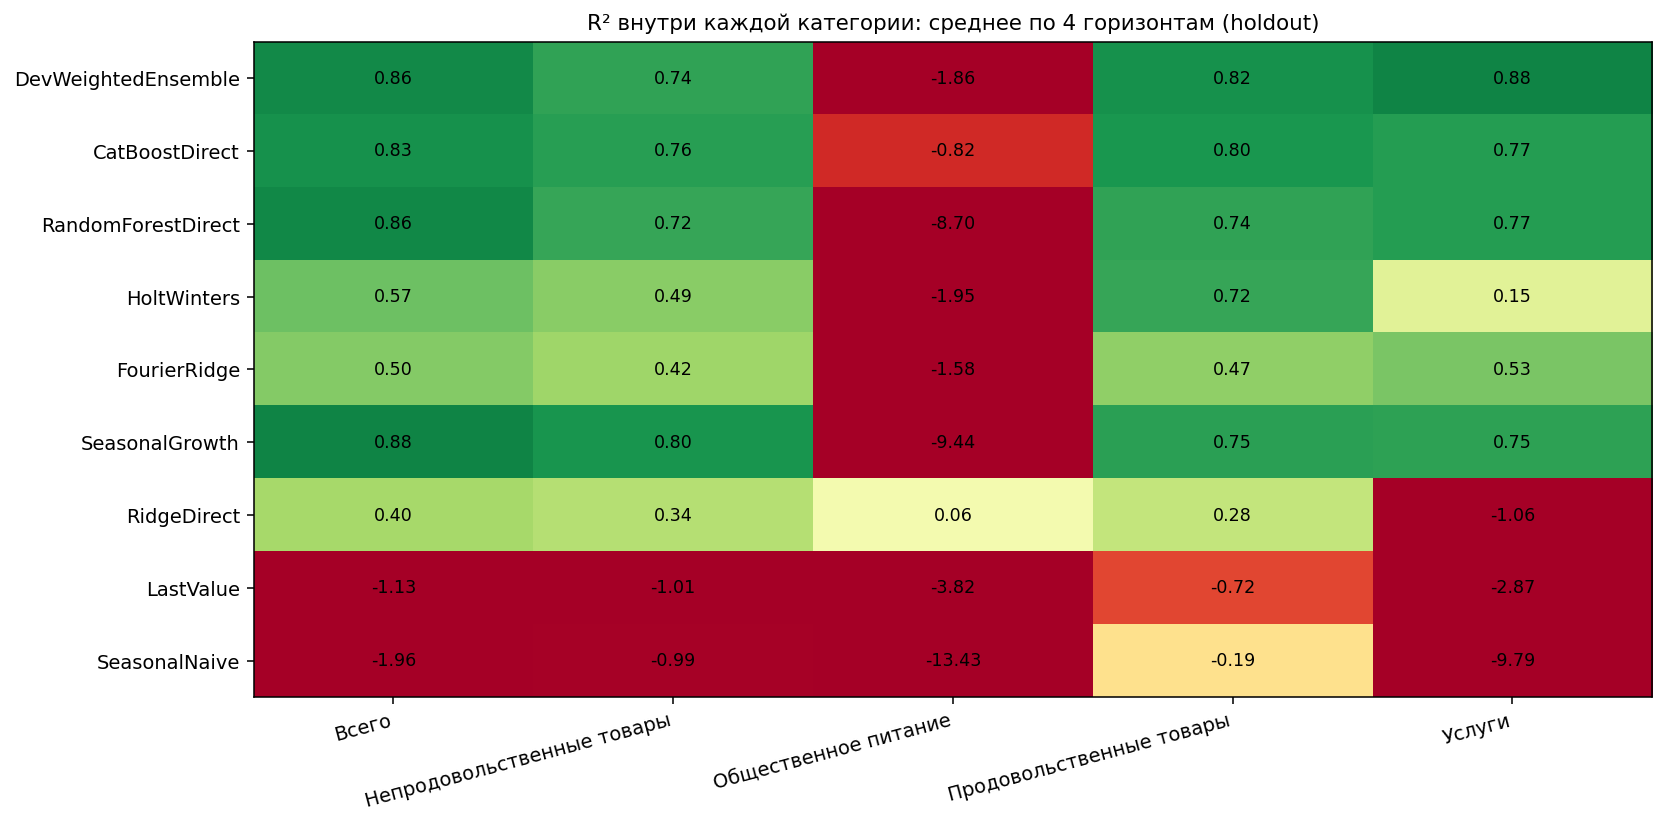

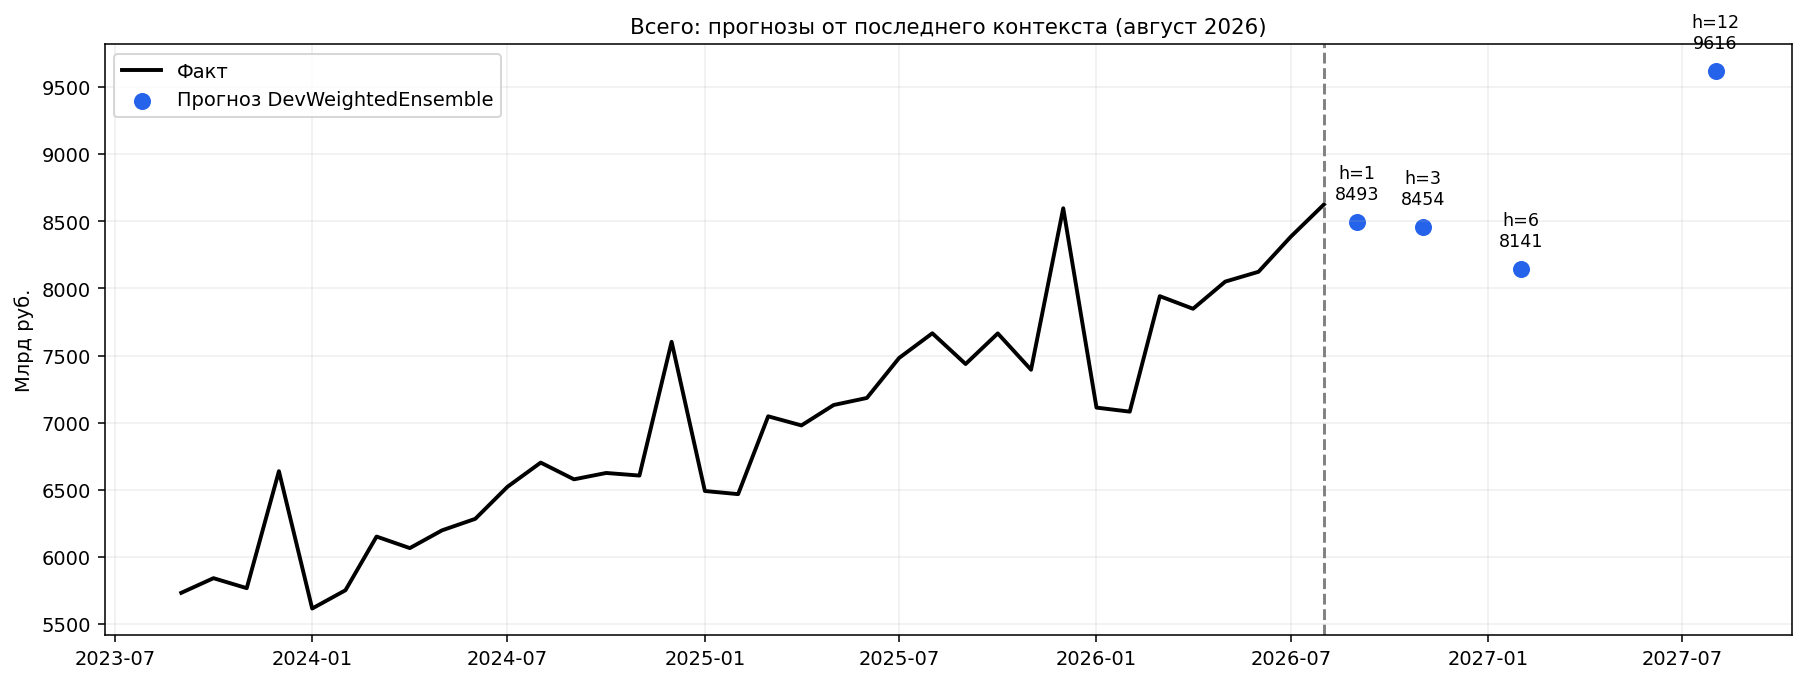

In [4]:
from src.forecast_report import render_report
result = render_report(ROOT, RUN)
display(pd.Series(result, name='value').to_frame())
for name in result['figures']:
    display(Image(filename=str(RUN / 'figures' / (name + '.png'))))

In [5]:
future = pd.read_csv(RUN / 'future_forecasts.csv')
chosen = future[future.model == result['selected_model']]
display(chosen.pivot(index='series_id', columns='horizon_months', values='y_pred').round(2))
display(Markdown('Это прогнозы от контекста августа 2026: сентябрь 2026, ноябрь 2026, февраль 2027 и август 2027. Фактов для этих целей в обучающей выгрузке нет. Прогнозы не являются будущими наблюдениями и не подтверждают эффективность раннего обнаружения шоков.'))
print('PDF:', result['pdf'])
print('Русскоязычный отчёт:', result['report'])
print('История запусков: tracking/national_forecast_metrics.csv')

PDF: artifacts/forecast_runs/national_20261003T112832_522037Z/forecast_comparison.pdf
Русскоязычный отчёт: docs/NATIONAL_FORECAST_RESULTS_RU.md
История запусков: tracking/national_forecast_metrics.csv


horizon_months,1,3,6,12
series_id,,,,
Всего,8493.35,8453.52,8141.08,9616.46
Непродовольственные товары,3277.03,3225.21,3069.28,3752.35
Общественное питание,545.80,542.80,576.41,682.87
Продовольственные товары,2760.50,2786.56,2716.37,3140.21
Услуги,1917.20,1924.03,1990.22,2133.73


Это прогнозы от контекста августа 2026: сентябрь 2026, ноябрь 2026, февраль 2027 и август 2027. Фактов для этих целей в обучающей выгрузке нет. Прогнозы не являются будущими наблюдениями и не подтверждают эффективность раннего обнаружения шоков.